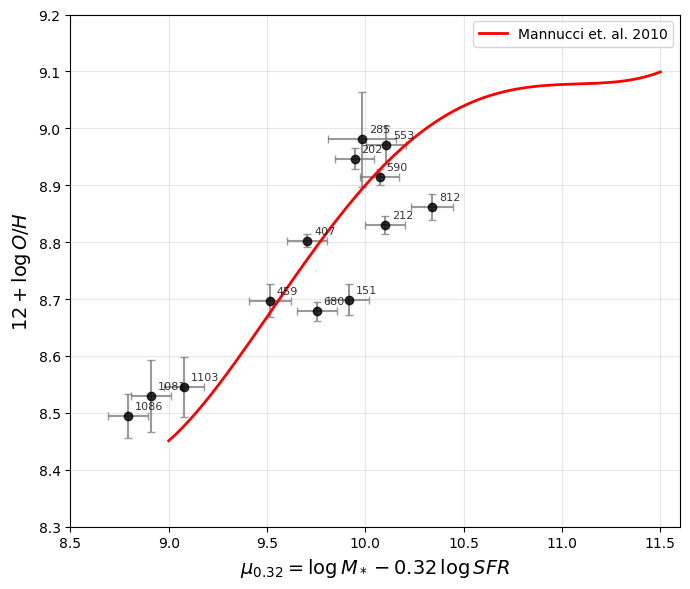

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. Load Data
# ==========================================================

df = pd.read_csv("LINES_FITS/new_flag_combined.csv")

# Select one entry per galaxy (max SFR, no bad Halpha flag)
df_sel = df.loc[
    df[(~df["flag_Ha_SN"])&
        (df["iden"]!=1483)&
        (df["iden"]!=101)&
        (df["iden"]!=1233)
]
    .groupby("iden")["SFR"]
    .idxmax()
].copy()

# ==========================================================
# 2. Compute μ_0.32
# ==========================================================

df_sel["mu32"] = df_sel["logM"] - 0.32 * df_sel["log10_SFR"]

# --- Error propagation ---
# σ²(μ) = σ²(logM) + (0.32)² σ²(logSFR)

# symmetric SFR error
sigma_logSFR = 0.5 * (
    df_sel["d_log10_SFR_up"] +
    df_sel["d_log10_SFR_low"]
)

sigma_logM = 0.1  # typical stellar mass uncertainty

df_sel["d_mu32"] = np.sqrt(
    sigma_logM**2 +
    (0.32**2) * sigma_logSFR**2
)

# ==========================================================
# 3. Convert PP04 O3N2 → Maiolino+08 scale
# ==========================================================

Z_pp04 = df_sel["12+log(O/H)"]

# Kewley & Ellison (2008) polynomial conversion
df_sel["Z_M08"] = (
    159.0567
    - 54.18511 * Z_pp04
    + 6.395364 * Z_pp04**2
    - 0.2471693 * Z_pp04**3
)

# --- Propagate metallicity uncertainties ---
dZ_dZpp = (
    -54.18511
    + 2 * 6.395364 * Z_pp04
    - 3 * 0.2471693 * Z_pp04**2
)

df_sel["Z_M08_err"] = np.abs(dZ_dZpp) * df_sel["12+log(O/H)_err"]


# ==========================================================
# 4. Mannucci+10 FMR eq 4
# ==========================================================

mu = df_sel["mu32"].values
x = mu - 10

df_sel["Z_FMR"] = (
    8.90
    + 0.39 * x
    - 0.20 * x**2
    - 0.077 * x**3
    + 0.064 * x **4
)

# ==========================================================
# 5. FMR curve for plotting
# ==========================================================

mu_grid = np.linspace(9, 11.5, 500)
x_grid = mu_grid - 10

Z_curve = (
    8.90
    + 0.39 * x_grid
    - 0.20 * x_grid**2
    - 0.077 * x_grid**3
    + 0.064 * x_grid**4
)


# ==========================================================
# 6. Plot
# ==========================================================

plt.figure(figsize=(7,6))

plt.errorbar(
    df_sel["mu32"],
    df_sel["Z_M08"],
    xerr=df_sel["d_mu32"],
    yerr=df_sel["Z_M08_err"],
    fmt='o',
    color="black",
    ecolor="gray",
    alpha=0.8,
    capsize=3
)

plt.plot(
    mu_grid,
    Z_curve,
    color="red",
    lw=2,
    label="Mannucci et. al. 2010"
)

# ==========================================================
# Add ID labels to each data point
# ==========================================================

for i, row in df_sel.iterrows():
    plt.annotate(
        str(row["iden"]),
        (row["mu32"], row["Z_M08"]),
        textcoords="offset points",
        xytext=(5, 5),   # small offset to avoid marker overlap
        fontsize=8,
        alpha=0.8
    )


plt.xlabel(r"$\mu_{0.32} = \log M_* - 0.32 \, \log SFR$", fontsize=14)
plt.ylabel(r"$12+ \log O/H$", fontsize=14)

plt.xlim(8.5, 11.6)
plt.ylim(8.3, 9.2)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("FMR_Mannucci.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
# ===============================================
# Convert Salpeter → Chabrier IMF
# ===============================================

logM_chab = df_sel["logM"] - np.log10(1.7)
M_chab = 10**logM_chab
SFR = df_sel["SFR"]

# sSFR in 1/yr
sSFR = SFR / M_chab

# Fit slope beta of log(sSFR) vs logM
coeff = np.polyfit(logM_chab, np.log10(sSFR), 1)
beta = coeff[0]

print("Measured beta =", beta)

Measured beta = -0.4724355787680584


In [11]:
def lilly_eq40(Z0_over_y,
               logy,
               lambda10,
               a,
               eps_inv_10,
               b,
               beta):

    R = 0.4
    t = 9.98  # Gyr (approx cluster redshift)

    y = 10**(logy - 12)   # convert to linear O/H
    Z0 = Z0_over_y * y

    # mass factor
    lambda_mass = lambda10 * (M_chab / 1e10)**a

    # star formation efficiency
    eps_inv = eps_inv_10 * (M_chab / 1e10)**(-b)

    # denominator
    denom = (
        1
        + lambda_mass / (1 - R)
        + eps_inv * (
            (1 + beta - b) * (SFR / M_chab)
            + (1 / (1 - R)) * (1.2 / t)
        )
    )

    #result
    Z_eq_linear = Z0 + y / denom

    # convert back to 12+log(O/H)
    Z_eq = 12 + np.log10(Z_eq_linear)

    return Z_eq

    # Primordial inflow
df_sel["Z_L13_prim"] = lilly_eq40(
    Z0_over_y=0.00,
    logy=9.02,
    lambda10=0.25,
    a=-0.81,
    eps_inv_10=2.4,
    b=0.28,
    beta=beta
)

# Metal-enriched inflow
df_sel["Z_L13_enriched"] = lilly_eq40(
    Z0_over_y=0.10,
    logy=8.98,
    lambda10=0.40,
    a=-0.77,
    eps_inv_10=3.8,
    b=0.41,
    beta=beta
)

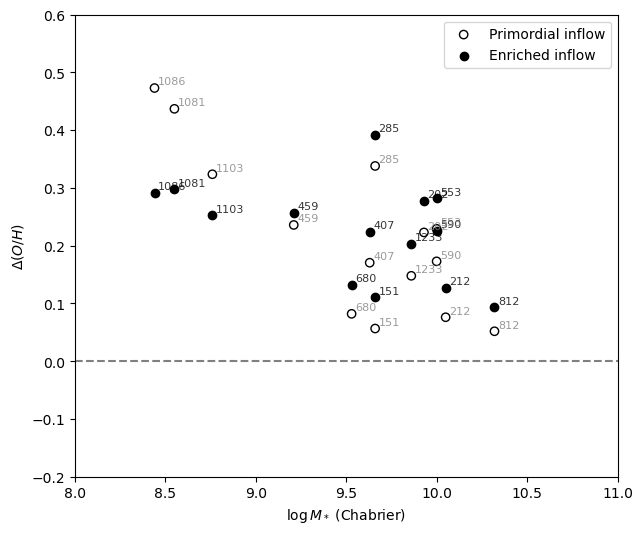

In [16]:
df_sel["delta_prim"] = df_sel["Z_M08"] - df_sel["Z_L13_prim"]
df_sel["delta_enriched"] = df_sel["Z_M08"] - df_sel["Z_L13_enriched"]

plt.figure(figsize=(7,6))

plt.scatter(logM_chab, df_sel["delta_prim"],
            facecolors='none', edgecolors='black',
            label="Primordial inflow")

plt.scatter(logM_chab, df_sel["delta_enriched"],
            color='black',
            label="Enriched inflow")

plt.axhline(0, ls='--', color='gray')


# =====================================================
# Add galaxy ID labels
# =====================================================
for i, row in df_sel.iterrows():
    plt.annotate(
        str(int(row["iden"])),
        (logM_chab[i], row["delta_enriched"]),
        textcoords="offset points",
        xytext=(2.5,2.5),
        fontsize=8,
        alpha=0.8,
        color="black"
    )
for i, row in df_sel.iterrows():
    plt.annotate(
        str(int(row["iden"])),
        (logM_chab[i], row["delta_prim"]),
        textcoords="offset points",
        xytext=(2.5,2.5),
        fontsize=8,
        alpha=0.8,
        color="grey"
    )


plt.xlabel(r"$\log M_*$ (Chabrier)")
plt.ylabel(r"$\Delta (O/H)$")
plt.xlim(8,11)
plt.ylim(-0.2, 0.6)
plt.legend()
plt.show()